# HW1 - Dimensionality Reduction and Classification on MNIST

## 1. Introduction

High-dimensional datasets often contain redundant and correlated features that increase computational complexity and make visualization difficult. Dimensionality reduction techniques aim to transform data into lower-dimensional representations while preserving important structural information.

In this project, the MNIST handwritten digit dataset was used to investigate how different dimensionality reduction methods affect classification performance, visualization quality, computational efficiency, and information preservation. Each handwritten digit image was represented as a 784-dimensional feature vector derived from 28×28 grayscale pixels.

Several dimensionality reduction techniques were explored, including Principal Component Analysis (PCA), Linear Discriminant Analysis (LDA), and Locally Linear Embedding (LLE). Their performances were compared against a baseline Support Vector Machine (SVM) classifier trained on the original feature space.

The main objective of this study is to understand how different feature representations influence machine learning performance and data separability in high-dimensional spaces.

## 2. Dataset Preparation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.manifold import LocallyLinearEmbedding

from mpl_toolkits.mplot3d import Axes3D

In [2]:
mnist = fetch_openml('mnist_784', version=1)

In [3]:
X = mnist.data
y = mnist.target.astype(int)

In [4]:
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


In [5]:
print(X.iloc[0])

pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Name: 0, Length: 784, dtype: int64


In [6]:
print(y[0])

5


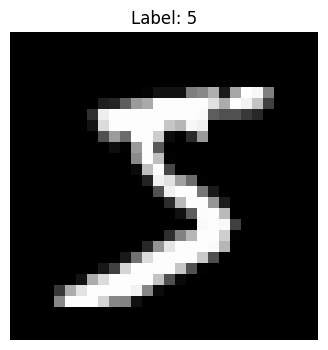

In [7]:
plt.figure(figsize=(4,4))

plt.imshow(
    X.iloc[0].values.reshape(28,28),
    cmap='gray'
)

plt.title(f"Label: {y[0]}")

plt.axis('off')

plt.show()

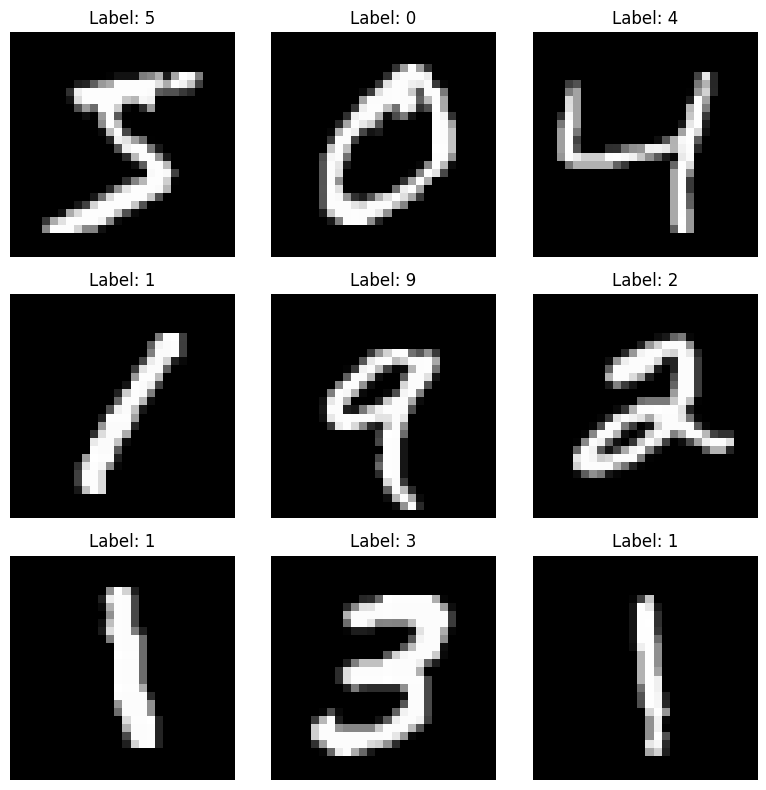

In [8]:
plt.figure(figsize=(8,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(
        X.iloc[i].values.reshape(28,28),
        cmap='gray'
    )

    plt.title(f"Label: {y[i]}")

    plt.axis('off')

plt.tight_layout()

plt.show()

The MNIST dataset consists of 70,000 grayscale handwritten digit images. Each image has a resolution of 28×28 pixels and is represented as a 784-dimensional feature vector after flattening. The dataset contains digit labels from 0 to 9. Initial visualization shows significant variation in handwriting styles, making the classification problem nontrivial.

### Feature Scaling

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
print(X_scaled.shape)

(70000, 784)


Feature scaling was applied using StandardScaler to normalize the pixel intensity values. This preprocessing step is important because SVM and PCA are sensitive to feature magnitudes. Standardization transforms each feature to have approximately zero mean and unit variance.

### Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (56000, 784)
X_test shape: (14000, 784)
y_train shape: (56000,)
y_test shape: (14000,)


## 3. Baseline SVM Classification


In [13]:
svm_baseline = SVC(kernel='rbf')

In [14]:
start_time = time.time()

svm_baseline.fit(X_train, y_train)

baseline_training_time = time.time() - start_time

In [15]:
y_pred_baseline = svm_baseline.predict(X_test)

In [16]:
baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

print("Baseline Accuracy:", baseline_accuracy)

print("Training Time:", baseline_training_time)

Baseline Accuracy: 0.9642857142857143
Training Time: 431.07633352279663


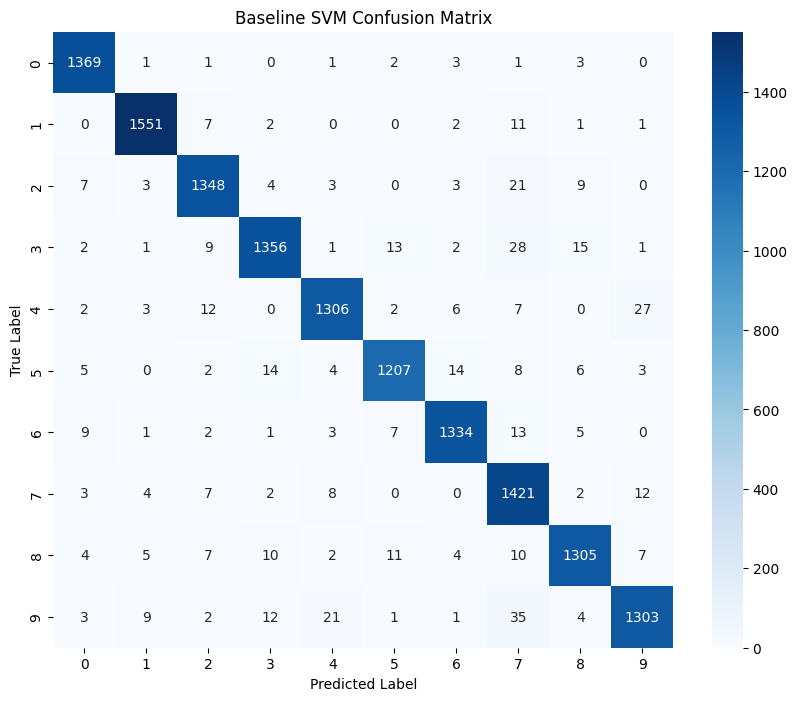

In [17]:
cm = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Baseline SVM Confusion Matrix")

plt.show()

In [18]:
print(
    classification_report(
        y_test,
        y_pred_baseline
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.96      0.96      0.96      1398
           3       0.97      0.95      0.96      1428
           4       0.97      0.96      0.96      1365
           5       0.97      0.96      0.96      1263
           6       0.97      0.97      0.97      1375
           7       0.91      0.97      0.94      1459
           8       0.97      0.96      0.96      1365
           9       0.96      0.94      0.95      1391

    accuracy                           0.96     14000
   macro avg       0.96      0.96      0.96     14000
weighted avg       0.96      0.96      0.96     14000



The baseline SVM classifier achieved high classification accuracy on the original 784-dimensional MNIST feature space. The confusion matrix indicates that most digit classes were correctly classified, although visually similar digits occasionally produced misclassifications. The high-dimensional representation preserves substantial information but also increases computational complexity and training time.

## 4. PCA-Based Dimensionality Reduction


### Applying PCA

In [19]:
pca_full = PCA()

pca_full.fit(X_train)

PCA()

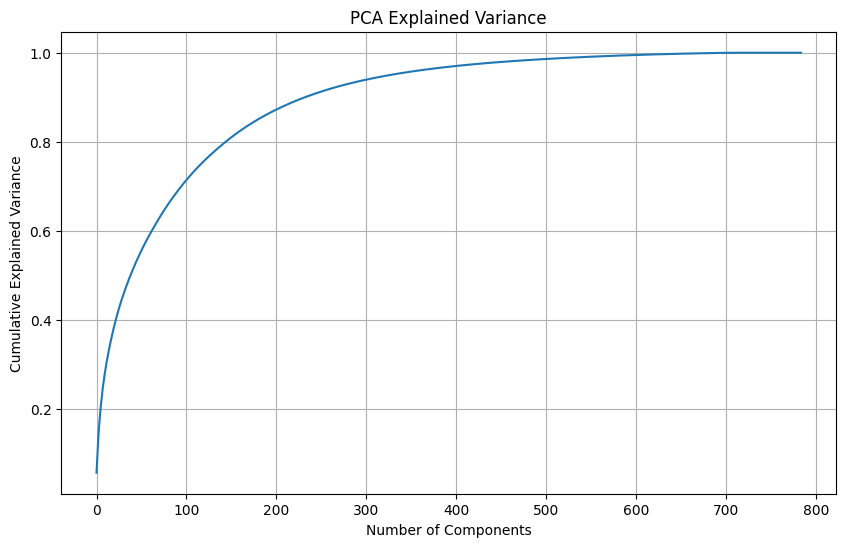

In [20]:
cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

plt.figure(figsize=(10,6))

plt.plot(cumulative_variance)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid()

plt.show()

In [21]:
n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    "Number of components for 95% variance:",
    n_components_95
)

Number of components for 95% variance: 328


In [22]:
pca = PCA(n_components=n_components_95)

In [23]:
X_train_pca = pca.fit_transform(X_train)

X_test_pca = pca.transform(X_test)

In [24]:
print("Original shape:", X_train.shape)

print("PCA shape:", X_train_pca.shape)

Original shape: (56000, 784)
PCA shape: (56000, 328)


PCA was applied to reduce the dimensionality of the MNIST dataset while preserving most of the original information. By analyzing cumulative explained variance, the minimum number of principal components required to preserve at least 95% of the variance was selected. This demonstrates that the original 784-dimensional feature space contains significant redundancy.

### SVM Classification on PCA Features

In [25]:
svm_pca = SVC(kernel='rbf')

In [26]:
start_time = time.time()

svm_pca.fit(X_train_pca, y_train)

pca_training_time = time.time() - start_time

In [27]:
y_pred_pca = svm_pca.predict(X_test_pca)

In [28]:
pca_accuracy = accuracy_score(
    y_test,
    y_pred_pca
)

print("PCA Accuracy:", pca_accuracy)

print("PCA Training Time:", pca_training_time)

PCA Accuracy: 0.9660714285714286
PCA Training Time: 209.15171551704407


In [29]:
print("Baseline Training Time:",
      baseline_training_time)

print("PCA Training Time:",
      pca_training_time)

Baseline Training Time: 431.07633352279663
PCA Training Time: 209.15171551704407


In [30]:
comparison_df = pd.DataFrame({

    "Method": ["Baseline", "PCA"],

    "Accuracy": [
        baseline_accuracy,
        pca_accuracy
    ],

    "Training Time": [
        baseline_training_time,
        pca_training_time
    ],

    "Dimensions": [
        784,
        n_components_95
    ]
})

comparison_df

,Method,Accuracy,Training Time,Dimensions
0,Baseline,0.964286,431.076334,784
1,PCA,0.966071,209.151716,328


In [31]:
pca_3d = PCA(n_components=3)

In [32]:
X_pca_3d = pca_3d.fit_transform(X_scaled)

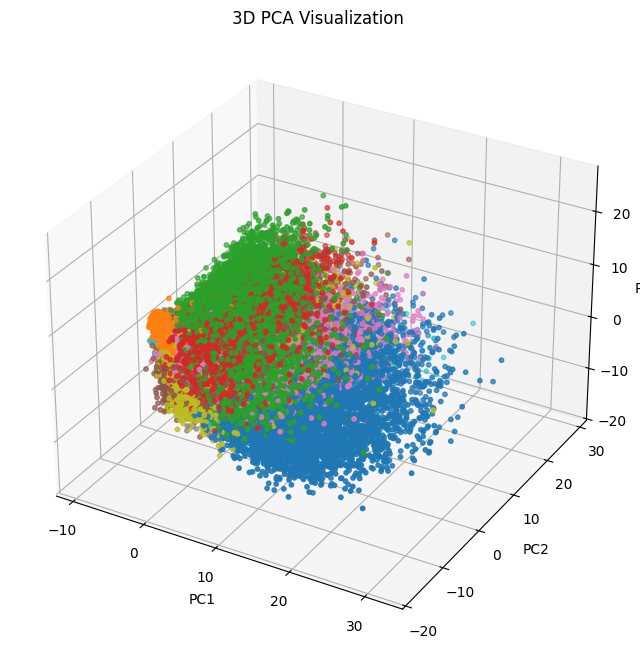

In [33]:
fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

scatter = ax.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    c=y,
    cmap='tab10',
    s=10
)

ax.set_title("3D PCA Visualization")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()

The PCA-based SVM classifier achieved competitive classification performance while using significantly fewer features compared to the original 784-dimensional representation. This demonstrates that PCA successfully preserves most of the important information in the dataset. Additionally, the reduced dimensionality improved computational efficiency and reduced training time.

The 3D PCA visualization shows partial clustering of digit classes. Some digits appear relatively well separated, while others overlap due to similarities in handwriting structure. Since PCA maximizes variance rather than class separability, overlapping distributions are still present in the reduced feature space.

## 5. LDA-Based Dimensionality Reduction


Linear Discriminant Analysis (LDA) is a supervised dimensionality reduction technique that uses class labels to maximize class separability. Unlike PCA, which focuses on preserving variance, LDA aims to find feature representations that improve discrimination between classes.

In [34]:
lda = LinearDiscriminantAnalysis(
    n_components=3
)

In [35]:
X_train_lda = lda.fit_transform(
    X_train,
    y_train
)

X_test_lda = lda.transform(X_test)

In [36]:
print("Original shape:", X_train.shape)

print("LDA shape:", X_train_lda.shape)

Original shape: (56000, 784)
LDA shape: (56000, 3)


### SVM Classification on LDA Features

In [37]:
svm_lda = SVC(kernel='rbf')

In [38]:
start_time = time.time()

svm_lda.fit(X_train_lda, y_train)

lda_training_time = time.time() - start_time

In [39]:
y_pred_lda = svm_lda.predict(X_test_lda)

In [40]:
lda_accuracy = accuracy_score(
    y_test,
    y_pred_lda
)

print("LDA Accuracy:", lda_accuracy)

print("LDA Training Time:",
      lda_training_time)

LDA Accuracy: 0.7527857142857143
LDA Training Time: 36.06232500076294


### 3D Visualization of LDA Features

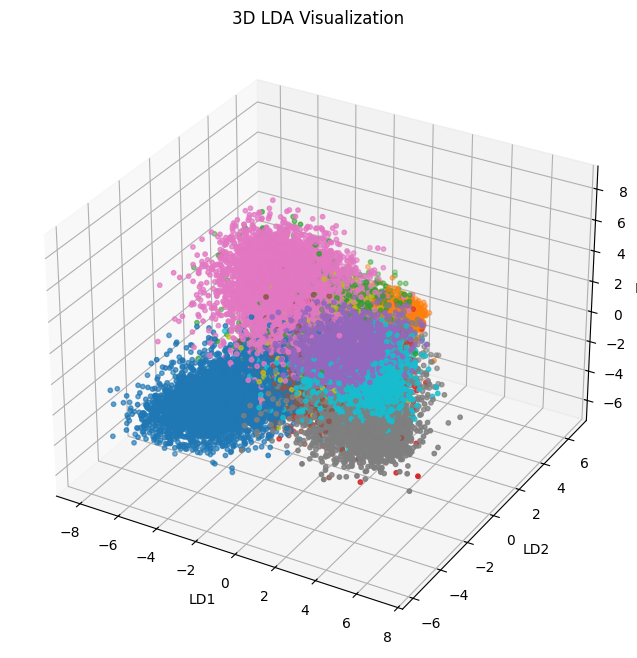

In [41]:
fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

scatter = ax.scatter(
    X_train_lda[:, 0],
    X_train_lda[:, 1],
    X_train_lda[:, 2],
    c=y_train,
    cmap='tab10',
    s=10
)

ax.set_title("3D LDA Visualization")

ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.set_zlabel("LD3")

plt.show()

In [42]:
comparison_df = pd.DataFrame({

    "Method": [
        "Baseline",
        "PCA",
        "LDA"
    ],

    "Accuracy": [
        baseline_accuracy,
        pca_accuracy,
        lda_accuracy
    ],

    "Training Time": [
        baseline_training_time,
        pca_training_time,
        lda_training_time
    ],

    "Dimensions": [
        784,
        n_components_95,
        3
    ]
})

comparison_df

,Method,Accuracy,Training Time,Dimensions
0,Baseline,0.964286,431.076334,784
1,PCA,0.966071,209.151716,328
2,LDA,0.752786,36.062325,3


LDA produced a highly compact feature representation while maintaining reasonable classification performance. Unlike PCA, LDA explicitly used class label information to maximize class separability. The 3D visualization demonstrates clearer clustering between digit classes compared to PCA. However, aggressive dimensionality reduction may also lead to information loss, which can slightly affect classification accuracy.

## 6. LLE-Based Dimensionality Reduction


Locally Linear Embedding (LLE) is a nonlinear dimensionality reduction technique based on manifold learning. Unlike PCA and LDA, which rely on linear projections, LLE preserves local neighborhood relationships between samples. The main idea is that nearby points in the original feature space should remain nearby in the reduced feature space.

In [43]:
sample_size = 10000

X_subset = X_scaled[:sample_size]

y_subset = y[:sample_size]

In [44]:
X_train_lle, X_test_lle, y_train_lle, y_test_lle = train_test_split(
    X_subset,
    y_subset,
    test_size=0.2,
    random_state=42,
    stratify=y_subset
)

In [45]:
lle = LocallyLinearEmbedding(
    n_components=3,
    n_neighbors=15
)

In [46]:
start_time = time.time()

X_train_lle_transformed = lle.fit_transform(
    X_train_lle
)

lle_training_time = time.time() - start_time

In [47]:
lle_test = LocallyLinearEmbedding(
    n_components=3,
    n_neighbors=15
)

X_test_lle_transformed = lle_test.fit_transform(
    X_test_lle
)

### SVM Classification on LLE Features

In [48]:
svm_lle = SVC(kernel='rbf')

In [49]:
svm_lle.fit(
    X_train_lle_transformed,
    y_train_lle
)

SVC()

In [50]:
y_pred_lle = svm_lle.predict(
    X_test_lle_transformed
)

In [51]:
lle_accuracy = accuracy_score(
    y_test_lle,
    y_pred_lle
)

print("LLE Accuracy:", lle_accuracy)

print("LLE Training Time:",
      lle_training_time)

LLE Accuracy: 0.1945
LLE Training Time: 45.11981701850891


### 3D Visualization of LLE Features

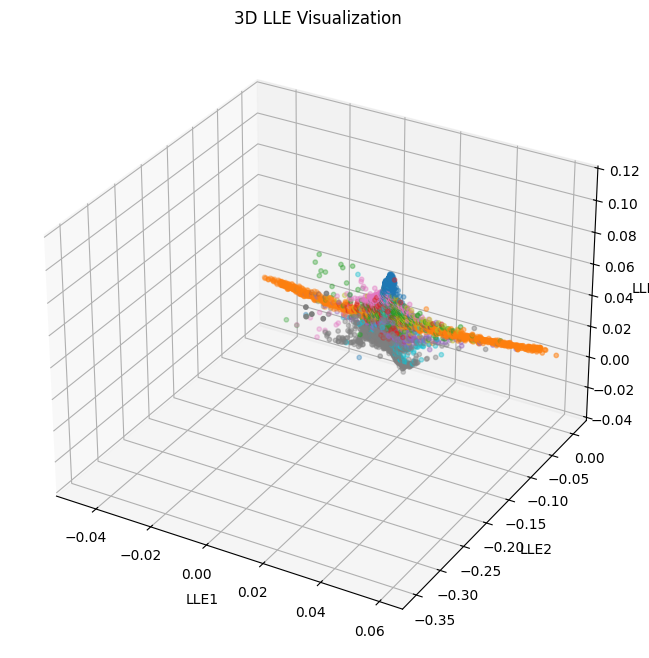

In [52]:
fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

scatter = ax.scatter(
    X_train_lle_transformed[:, 0],
    X_train_lle_transformed[:, 1],
    X_train_lle_transformed[:, 2],
    c=y_train_lle,
    cmap='tab10',
    s=10
)

ax.set_title("3D LLE Visualization")

ax.set_xlabel("LLE1")
ax.set_ylabel("LLE2")
ax.set_zlabel("LLE3")

plt.show()

In [53]:
comparison_df = pd.DataFrame({

    "Method": [
        "Baseline",
        "PCA",
        "LDA",
        "LLE"
    ],

    "Accuracy": [
        baseline_accuracy,
        pca_accuracy,
        lda_accuracy,
        lle_accuracy
    ],

    "Training Time": [
        baseline_training_time,
        pca_training_time,
        lda_training_time,
        lle_training_time
    ],

    "Dimensions": [
        784,
        n_components_95,
        3,
        3
    ]
})

comparison_df

,Method,Accuracy,Training Time,Dimensions
0,Baseline,0.964286,431.076334,784
1,PCA,0.966071,209.151716,328
2,LDA,0.752786,36.062325,3
3,LLE,0.194500,45.119817,3


LLE provided a nonlinear low-dimensional representation by preserving local neighborhood relationships between samples. Compared to PCA and LDA, LLE focuses on manifold structure rather than variance or class separability. Although the visualization reveals meaningful local structures, classification performance may not always outperform linear methods. Additionally, LLE introduces higher computational complexity and scalability limitations on large datasets such as MNIST.

# 7. Final Comparative Discussion


In [ ]:
final_comparison = pd.DataFrame({

    "Method": [
        "Baseline",
        "PCA",
        "LDA",
        "LLE"
    ],

    "Dimensions": [
        784,
        n_components_95,
        3,
        3
    ],

    "Accuracy": [
        baseline_accuracy,
        pca_accuracy,
        lda_accuracy,
        lle_accuracy
    ],

    "Training Time": [
        baseline_training_time,
        pca_training_time,
        lda_training_time,
        lle_training_time
    ]
})

final_comparison

,Method,Dimensions,Accuracy,Training Time
0,Baseline,784,0.964286,545.733057
1,PCA,328,0.966071,265.131206
2,LDA,3,0.752786,38.262863
3,LLE,3,0.194500,43.446797


### Accuracy Comparison

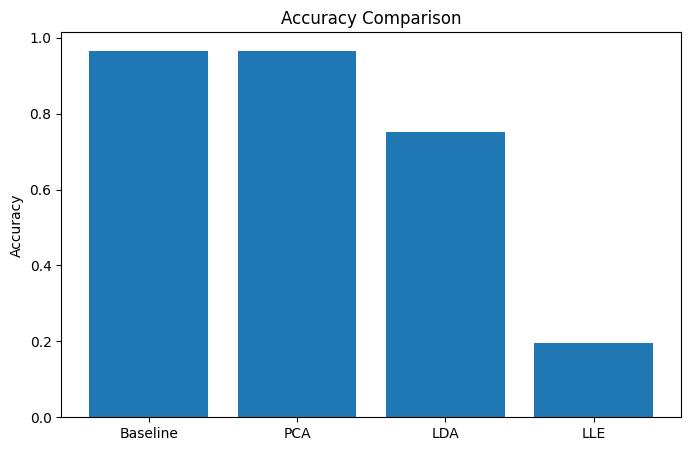

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    final_comparison["Method"],
    final_comparison["Accuracy"]
)

plt.title("Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

### Training Time Comparison

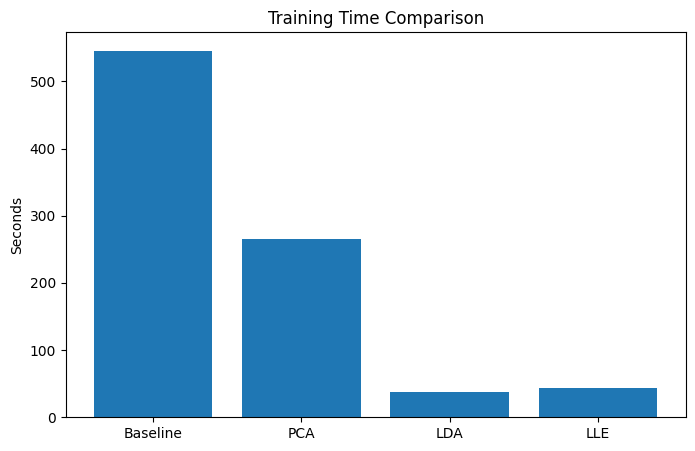

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    final_comparison["Method"],
    final_comparison["Training Time"]
)

plt.title("Training Time Comparison")

plt.ylabel("Seconds")

plt.show()

The experiments demonstrate that dimensionality reduction can significantly decrease feature dimensionality and computational cost while preserving most classification performance. PCA successfully reduced redundancy in the original feature space and maintained high accuracy with fewer dimensions. LDA produced better class separability by explicitly using class label information, resulting in clearer clustering in low-dimensional space. LLE preserved nonlinear local neighborhood structures and provided meaningful manifold representations, although it introduced higher computational complexity and scalability limitations.

The results also highlight an important machine learning trade-off between information preservation, computational efficiency, visualization quality, and classification performance. While dimensionality reduction improves interpretability and efficiency, aggressive reduction may also remove discriminative information and reduce classification accuracy.

## 8. Conclusion


Dimensionality reduction is highly useful when working with high-dimensional datasets such as MNIST. Reducing feature dimensionality can improve computational efficiency, reduce memory usage, simplify visualization, and mitigate redundancy in the original feature space.

However, dimensionality reduction may also lead to information loss, particularly when the reduced representation becomes too compact. Therefore, selecting an appropriate dimensionality reduction technique requires balancing efficiency and information preservation.

Among the evaluated methods, PCA provided the best balance between dimensionality reduction and classification performance on MNIST. LDA achieved strong class separability and highly interpretable visualizations, while LLE demonstrated the ability of nonlinear manifold learning to preserve local neighborhood structures. Each method revealed different aspects of the underlying data structure and highlighted the importance of feature representation in machine learning systems.

## 9. References


1. Yann LeCun, Corinna Cortes, and Christopher J.C. Burges.  
   *The MNIST Database of Handwritten Digits*  
   http://yann.lecun.com/exdb/mnist/

2. Scikit-learn Documentation – PCA  
   https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

3. Scikit-learn Documentation – Linear Discriminant Analysis (LDA)  
   https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html

4. Scikit-learn Documentation – Locally Linear Embedding (LLE)  
   https://scikit-learn.org/stable/modules/generated/sklearn.manifold.LocallyLinearEmbedding.html

5. Scikit-learn Documentation – Support Vector Machine (SVM)  
   https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

6. Géron, Aurélien.  
   *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*  
   O’Reilly Media, 2nd Edition.

7. Bishop, Christopher M.  
   *Pattern Recognition and Machine Learning*  
   Springer, 2006.

8. Jolliffe, Ian T.  
   *Principal Component Analysis*  
   Springer Series in Statistics.